# Continuous agentic engineering: a living compressor task
**Version 1.0.0 · Even Solbraa · synthetic teaching case · 27 September 2026**

This companion to *Continuous Agentic Engineering with NeqSim*, Chapter 9,
shows a complete sequence: solve a three-train compression problem, detect changed
conditions, reject a stale proposal, investigate alternatives and retain a proposal
for engineering review. Chapters 2, 5–7 and 11 explain the agent/skill boundary,
living-task contract, review and separation of model changes from plant changes.

**Read the saved results, then use Runtime → Run all in a fresh Colab runtime.**
The source build can take several minutes. No API key is needed for the physics
and explicitly scripted teaching replay. To run a real language model, configure
Section 8 and run its cell. A ChatGPT subscription is not an API credential.

This notebook is a bounded Python adapter for the public agent instructions. It
is not an installation of a Copilot agent, a historian service or an automatic
plant controller. NeqSim computes physical results; a language model can choose
which exposed calculations to request. No facility measurements or field names
are used. No proposal is applied to real equipment.

## 1. Build the same NeqSim source before importing the Python bridge
The pinned commit was current `equinor/neqsim` master when this example was built.
The released Python package supplies the JPype bridge; Java calculations use the
source-built JAR. The printed commit, JAR hash and class location make this
inspectable. Restart the runtime if a JVM is already running.

For clean local validation, `NEQSIM_SOURCE_ROOT` and `NEQSIM_SOURCE_JAR` may point
to this exact checkout and its built JAR. All provenance checks still run.

In [1]:
import hashlib
import importlib.util
import json
import math
import os
import platform
import subprocess
import sys
from importlib.metadata import version
from pathlib import Path

NEQSIM_SOURCE_REF = "c53327e166448312291b4023c24b58f989c05a33"
packages = ["neqsim==3.20.0", "numpy", "pandas", "matplotlib", "openai==3.19.2"]
missing = []
for item in packages:
    package, _, pinned_version = item.partition("==")
    if importlib.util.find_spec(package) is None:
        missing.append(item)
    elif pinned_version and version(package) != pinned_version:
        missing.append(item)
if missing:
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", *missing], check=True)

source_override = os.environ.get("NEQSIM_SOURCE_ROOT")
source_root = Path(source_override or "neqsim-compressor-source").resolve()
if not source_override:
    if not (source_root / ".git").exists():
        subprocess.run([
            "git", "clone", "--filter=blob:none", "--no-checkout",
            "https://github.com/equinor/neqsim.git", str(source_root),
        ], check=True, capture_output=True)
    subprocess.run(
        ["git", "fetch", "origin", NEQSIM_SOURCE_REF], cwd=source_root,
        check=True, capture_output=True,
    )
    subprocess.run(
        ["git", "checkout", "--detach", NEQSIM_SOURCE_REF], cwd=source_root,
        check=True, capture_output=True,
    )
    wrapper = "mvnw.cmd" if os.name == "nt" else "./mvnw"
    build = subprocess.run(
        [wrapper, "-q", "-Dmaven.test.skip=true", "-Dmaven.javadoc.skip=true", "package"],
        cwd=source_root, capture_output=True, text=True,
    )
    if build.returncode:
        raise RuntimeError("Source build failed:\n" + build.stdout[-3000:] + build.stderr[-3000:])

source_commit = subprocess.check_output(
    ["git", "rev-parse", "HEAD"], cwd=source_root, text=True,
).strip()
assert source_commit == NEQSIM_SOURCE_REF
subprocess.run(
    ["git", "diff", "--exit-code", "HEAD", "--", "pom.xml", "src/main"],
    cwd=source_root, check=True, capture_output=True,
)
source_jar = Path(os.environ.get(
    "NEQSIM_SOURCE_JAR", str(source_root / "target/neqsim-3.22.0.jar"),
)).resolve()
assert source_jar.is_file(), "Build the source JAR before running this cell."
os.environ["NEQSIM_JVM_AUTOSTART"] = "0"
import jpype

if jpype.isJVMStarted():
    raise RuntimeError("Restart the runtime: source JAR must be loaded first.")
jpype.addClassPath(str(source_jar))
from neqsim.neqsimpython import init_jvm

init_jvm()
from neqsim import jneqsim

runtime_class = jpype.JClass("neqsim.process.operations.continuous.ImprovementCycle")
loaded_from = str(runtime_class.class_.getProtectionDomain().getCodeSource().getLocation())
assert source_jar.as_uri() == loaded_from.replace("file:/", "file:///", 1)
PROVENANCE = {
    "source_commit": source_commit,
    "jar_sha256": hashlib.sha256(source_jar.read_bytes()).hexdigest(),
    "loaded_from": loaded_from,
    "python": platform.python_version(),
    "java": str(jpype.JClass("java.lang.System").getProperty("java.version")),
    "packages": {name: version(name) for name in ["neqsim", "numpy", "pandas", "openai"]},
}
print(json.dumps(PROVENANCE, indent=2))

{
  "source_commit": "c53327e166448312291b4023c24b58f989c05a33",
  "jar_sha256": "13f8499c79fb3be33d6efa69f459e4f79e7daa7cef4ea75a3dee26f4fa9ddd9a",
  "loaded_from": "file:/content/neqsim-compressor-source/target/neqsim-3.22.0.jar",
  "python": "3.13.15",
  "java": "21.0.12",
  "packages": {
    "neqsim": "3.20.0",
    "numpy": "2.1.3",
    "pandas": "2.2.3",
    "openai": "3.19.2"
  }
}


## 2. State the engineering goal and limits
**Goal:** maximize gas throughput, with a retained target of 100.8 kg/s, while
respecting the power, cooling, temperature and flow screening limits below.

| Quantity | Synthetic basis |
|---|---|
| Feed | 37 °C; 42 bara initially, later 39 bara |
| Export | 92 bara; aftercooled to 40 °C |
| Gas mole fractions | methane 0.910, ethane 0.055, propane 0.018, CO₂ 0.007, nitrogen 0.010 |
| EOS | SRK, mixing rule 2, multiphase check enabled |
| Isentropic efficiencies A/B/C | 0.79 / 0.75 / 0.81 |
| Shaft ceiling | 5 MW per train |
| Flow screening envelope | 20–42 kg/s per train; 115 kg/s supply ceiling |
| Inlet cooling candidates | 29–37 °C, at most 2.8 MW total heat removal |
| Electrical allocation | 16 MW initially; 14 MW during curtailment |
| Motor and auxiliary assumptions | motor efficiency 0.97; fixed auxiliaries 0.40 MW; cooling auxiliaries 0.10 MW when active |

The electrical constraint is
$$P_{elec}=\frac{P_A+P_B+P_C}{0.97}+0.40+P_{cool,aux}\le P_{available}.$$
All powers are in MW. The cooling auxiliary is an assumed load, not a refrigeration
model. The model has fixed efficiencies and pressures, no pressure losses and no
vendor compressor maps. Flow limits are **not** surge/choke limits. This is a
power-limited screening study, not equipment qualification or a control policy.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

plt.rcParams.update({"figure.dpi": 130, "font.size": 10})
TRAIN_NAMES = ["A", "B", "C"]
GOAL_KG_S = 100.8

In [3]:
COMPOSITION = {
    "methane": 0.910,
    "ethane": 0.055,
    "propane": 0.018,
    "CO2": 0.007,
    "nitrogen": 0.010,
}
EFFICIENCIES = [0.79, 0.75, 0.81]
POWER_LIMIT_MW = 5.0
SUPPLY_LIMIT_KG_S = 115.0
COOLING_LIMIT_MW = 2.8
MOTOR_EFFICIENCY = 0.97
FIXED_AUX_MW = 0.40
COOLING_AUX_MW = 0.10

### Build a complete process for every candidate
The feed is split into three parallel trains. Each train has an inlet cooler,
compressor and aftercooler; the outlets are mixed. Building a fresh ProcessSystem
prevents hidden state from an earlier trial. Each result carries its constraints
and mass/energy checks, so the agent cannot turn a failed calculation into an
accepted proposal merely by describing it confidently.

In [4]:
def evaluate(flows, inlet_c=37.0, efficiencies=None, suction_bara=42.0,
             available_electric_mw=16.0):
    """Build and run a fresh, complete three-train NeqSim ProcessSystem."""
    efficiencies = EFFICIENCIES if efficiencies is None else efficiencies
    fluid = jneqsim.thermo.system.SystemSrkEos(310.15, suction_bara)
    for component, fraction in COMPOSITION.items():
        fluid.addComponent(component, fraction)
    fluid.setMixingRule(2)
    fluid.setMultiPhaseCheck(True)
    fluid.setTotalFlowRate(float(sum(flows)), "kg/sec")
    feed = jneqsim.process.equipment.stream.Stream("station feed", fluid)
    splitter = jneqsim.process.equipment.splitter.Splitter("feed split", feed, 3)
    fractions = jpype.JArray(jpype.JDouble)([f / sum(flows) for f in flows])
    splitter.setSplitFactors(fractions)
    process = jneqsim.process.processmodel.ProcessSystem()
    process.add(feed)
    process.add(splitter)
    mixer = jneqsim.process.equipment.mixer.Mixer("export mixer")
    compressors = []
    precoolers = []
    aftercoolers = []
    for index, eta in enumerate(efficiencies):
        name = chr(65 + index)
        cooler = jneqsim.process.equipment.heatexchanger.Cooler(
            "inlet cooler " + name, splitter.getSplitStream(index)
        )
        cooler.setOutTemperature(float(inlet_c + 273.15))
        compressor = jneqsim.process.equipment.compressor.Compressor(
            "compressor " + name, cooler.getOutletStream()
        )
        compressor.setOutletPressure(92.0)
        compressor.setIsentropicEfficiency(float(eta))
        aftercooler = jneqsim.process.equipment.heatexchanger.Cooler(
            "aftercooler " + name, compressor.getOutletStream()
        )
        aftercooler.setOutTemperature(313.15)
        for unit in [cooler, compressor, aftercooler]:
            process.add(unit)
        mixer.addStream(aftercooler.getOutletStream())
        compressors.append(compressor)
        precoolers.append(cooler)
        aftercoolers.append(aftercooler)
    process.add(mixer)
    process.run()
    powers = [float(c.getPower("MW")) for c in compressors]
    out_t = [float(c.getOutletStream().getTemperature("C")) for c in compressors]
    signed_duties_w = [float(c.getDuty()) for c in precoolers + aftercoolers]
    inlet_cooling_mw = -sum(float(c.getDuty()) for c in precoolers) / 1e6
    auxiliary_mw = FIXED_AUX_MW + (COOLING_AUX_MW if inlet_c < 37.0 else 0.0)
    electric_mw = sum(powers) / MOTOR_EFFICIENCY + auxiliary_mw
    mass_error = abs(float(feed.getFlowRate("kg/sec")) -
                     float(mixer.getOutletStream().getFlowRate("kg/sec")))
    delta_h = (float(mixer.getOutletStream().getFluid().getEnthalpy()) -
               float(feed.getFluid().getEnthalpy()))
    energy_error_w = abs(delta_h - sum(powers) * 1e6 - sum(signed_duties_w))
    streams = [feed, mixer.getOutletStream()]
    streams += [unit.getOutletStream() for unit in precoolers + compressors + aftercoolers]
    phases = [int(s.getFluid().getNumberOfPhases()) for s in streams]
    values = powers + out_t + [inlet_cooling_mw, mass_error, energy_error_w]
    checks = {
        "finite": all(math.isfinite(value) for value in values),
        "single_phase": all(n == 1 for n in phases),
        "mass_balance": mass_error < 1e-6,
        "energy_balance": energy_error_w < 10.0,
        "pressure": abs(float(mixer.getOutletStream().getPressure("bara")) - 92.0) < 1e-8,
        "positive_power": all(power > 0.0 for power in powers),
        "power_limits": all(power <= POWER_LIMIT_MW + 1e-5 for power in powers),
        "temperature_limits": all(temperature < 125.0 for temperature in out_t),
        "flow_limits": all(20.0 <= flow <= 42.0 for flow in flows),
        "supply_limit": sum(flows) <= SUPPLY_LIMIT_KG_S,
        "cooling_limit": inlet_cooling_mw <= COOLING_LIMIT_MW + 1e-6,
        "electric_limit": electric_mw <= available_electric_mw + 1e-5,
    }
    return {
        "flows_kg_s": flows,
        "total_flow_kg_s": sum(flows),
        "inlet_c": inlet_c,
        "suction_bara": suction_bara,
        "efficiencies": efficiencies,
        "powers_mw": powers,
        "total_shaft_power_mw": sum(powers),
        "total_electric_power_mw": electric_mw,
        "available_electric_mw": available_electric_mw,
        "discharge_c": out_t,
        "inlet_cooling_mw": inlet_cooling_mw,
        "mass_error_kg_s": mass_error,
        "energy_error_w": energy_error_w,
        "checks": checks,
        "feasible": all(checks.values()),
    }

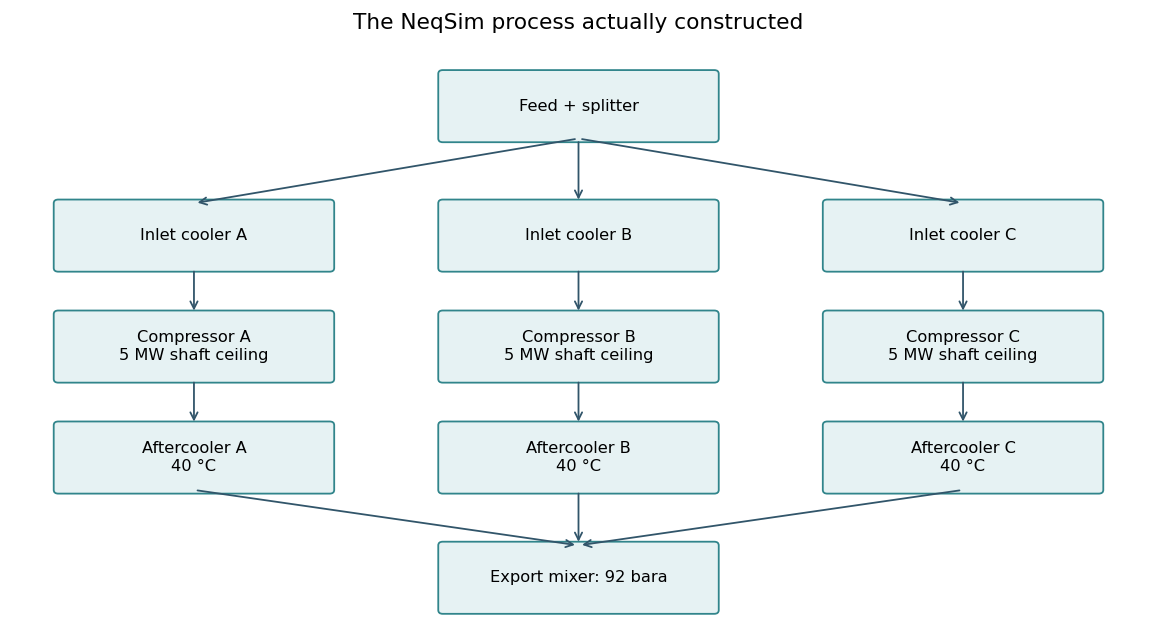

In [5]:
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(9, 5))
ax.set(xlim=(0, 10), ylim=(-0.2, 6))
ax.axis("off")
def box(x, y, text, width=2.4):
    patch = FancyBboxPatch(
        (x - width / 2, y - 0.35), width, 0.7,
        boxstyle="round,pad=0.04", facecolor="#e6f2f3", edgecolor="#31858b",
    )
    ax.add_patch(patch)
    ax.text(x, y, text, ha="center", va="center", fontsize=9)

def arrow(start, end):
    ax.annotate("", xy=end, xytext=start, arrowprops={"arrowstyle": "->", "color": "#31556a"})

box(5, 5.4, "Feed + splitter")
for x, name in zip([1.6, 5, 8.4], TRAIN_NAMES):
    box(x, 4.0, "Inlet cooler " + name)
    box(x, 2.8, "Compressor " + name + "\n5 MW shaft ceiling")
    box(x, 1.6, "Aftercooler " + name + "\n40 °C")
    arrow((5, 5.05), (x, 4.35))
    arrow((x, 3.65), (x, 3.15))
    arrow((x, 2.45), (x, 1.95))
    arrow((x, 1.25), (5, 0.65))
box(5, 0.3, "Export mixer: 92 bara")
ax.set_title("The NeqSim process actually constructed", pad=12)
plt.tight_layout()
plt.show()

## 3. Solve the initial problem and establish a reproducible reference
With fixed fluid, pressures, temperatures and efficiencies, shaft power is
proportional to branch flow. The allocation below first meets the stipulated
minimum flows, then assigns the remaining shaft budget to the lowest-specific-work
train within its limits. Every proposed allocation is rerun in the full process.
This linear allocation rule is specific to this simplified model and must be
replaced when maps, nonlinear pressure losses or other coupling are introduced.

In [6]:
def capacity(inlet_c, efficiencies=None, suction_bara=42.0,
             available_electric_mw=16.0):
    """Scale fixed-efficiency specific work, then rerun the full station.

    Extensive power is linear in mass flow only under the declared fixed
    pressures, temperatures, composition and efficiencies of this model.
    """
    probe = evaluate([30.0] * 3, inlet_c, efficiencies, suction_bara)
    specific_power = [p / 30.0 for p in probe["powers_mw"]]
    upper_flows = [min(42.0, POWER_LIMIT_MW / w) for w in specific_power]
    auxiliary_mw = FIXED_AUX_MW + (COOLING_AUX_MW if inlet_c < 37.0 else 0.0)
    shaft_budget = (available_electric_mw - auxiliary_mw) * MOTOR_EFFICIENCY
    flows = [20.0] * 3
    remaining = shaft_budget - sum(f * w for f, w in zip(flows, specific_power))
    if remaining < 0.0:
        raise ValueError("Power budget cannot sustain the stipulated minimum flows")
    for index in sorted(range(3), key=lambda i: specific_power[i]):
        addition = min(upper_flows[index] - flows[index], remaining / specific_power[index])
        flows[index] += max(0.0, addition)
        remaining -= max(0.0, addition) * specific_power[index]
    if sum(flows) > SUPPLY_LIMIT_KG_S:
        flows = [f * SUPPLY_LIMIT_KG_S / sum(flows) for f in flows]
    return evaluate(flows, inlet_c, efficiencies, suction_bara, available_electric_mw)

,Inlet °C,Flow kg/s,Shaft MW,Electric MW,Cooling MW,Feasible
0,29.0,102.985,15.0,15.964,2.006,True
1,30.0,102.545,15.0,15.964,1.747,True
2,31.0,102.109,15.0,15.964,1.491,True
3,32.0,101.678,15.0,15.964,1.237,True
4,33.0,101.252,15.0,15.964,0.986,True
5,34.0,100.830,15.0,15.964,0.736,True
6,35.0,100.413,15.0,15.964,0.489,True
7,36.0,100.000,15.0,15.964,0.243,True
8,37.0,99.591,15.0,15.864,-0.000,True


,Train,Flow kg/s,Shaft MW,Discharge °C
0,A,34.620,5.0,100.986
1,B,32.867,5.0,103.824
2,C,35.497,5.0,99.673


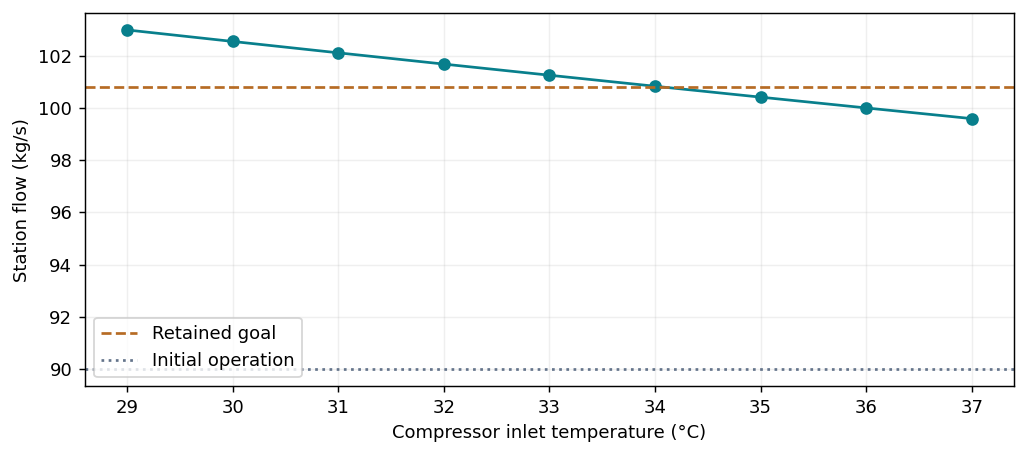

Initial operation: 90.00 kg/s.
Best tested screening case: 102.98 kg/s.


In [7]:
baseline = evaluate([30.0, 30.0, 30.0])
trials = [capacity(float(temperature)) for temperature in range(29, 38)]
best = max((row for row in trials if row["feasible"]), key=lambda row: row["total_flow_kg_s"])
assert baseline["feasible"] and best["feasible"]
trial_table = pd.DataFrame([{
    "Inlet °C": row["inlet_c"],
    "Flow kg/s": row["total_flow_kg_s"],
    "Shaft MW": row["total_shaft_power_mw"],
    "Electric MW": row["total_electric_power_mw"],
    "Cooling MW": row["inlet_cooling_mw"],
    "Feasible": row["feasible"],
} for row in trials])
display(trial_table.round(3))
display(pd.DataFrame({
    "Train": TRAIN_NAMES, "Flow kg/s": best["flows_kg_s"],
    "Shaft MW": best["powers_mw"], "Discharge °C": best["discharge_c"],
}).round(3))
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(trial_table["Inlet °C"], trial_table["Flow kg/s"], "o-", color="#087f8c")
ax.axhline(GOAL_KG_S, linestyle="--", color="#b66b24", label="Retained goal")
ax.axhline(90, linestyle=":", color="#64748b", label="Initial operation")
ax.set(xlabel="Compressor inlet temperature (°C)", ylabel="Station flow (kg/s)")
ax.legend(loc="lower left")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()
print(f"Initial operation: {baseline['total_flow_kg_s']:.2f} kg/s.")
print(f"Best tested screening case: {best['total_flow_kg_s']:.2f} kg/s.")

The efficient trains take more gas. The gain over the initial 90 kg/s uses
previously unused power as well as a different allocation and cooling; it is not
an energy-efficiency gain at fixed production. “Best” means best of the nine
tested inlet temperatures under this simplified allocation model.

## 4. Make the solved task live: observe, invalidate and recompute
This is a twelve-cycle synthetic replay, not a connection to a running facility.
Cycle 5 lowers suction pressure; cycle 8 reduces the approved electrical
allocation; cycle 11 restores it. On each change, the old proposal is tested
against the new constraints before reuse. A direct input-change detector is
sufficient for these prescribed events; no alarm lead-time or false-alarm claim
is made.

The comparison uses equal train flows at the **same** suction pressure, power
allocation and cooling temperature. Restored external power is never counted as
an agent-created gain. Each next cycle assumes hypothetical reviewer acceptance
for teaching only; no real acceptance or plant change is recorded.

In [8]:
snapshots = [{
    "cycle": day,
    "timestamp_utc": f"2026-09-{day:02d}T06:00:00Z",
    "suction_bara": 42.0 if day < 5 else 39.0,
    "available_electric_mw": 14.0 if 8 <= day <= 10 else 16.0,
} for day in range(1, 13)]

def solve_snapshot(snapshot):
    candidates = [capacity(
        float(temperature), suction_bara=snapshot["suction_bara"],
        available_electric_mw=snapshot["available_electric_mw"],
    ) for temperature in range(29, 38)]
    return max(
        (item for item in candidates if item["feasible"]),
        key=lambda item: item["total_flow_kg_s"],
    )

def equal_share_reference(snapshot, inlet_c):
    probe = evaluate([30.0] * 3, inlet_c, suction_bara=snapshot["suction_bara"])
    work = [power / 30.0 for power in probe["powers_mw"]]
    auxiliary = FIXED_AUX_MW + (COOLING_AUX_MW if inlet_c < 37 else 0.0)
    equal_flow = min(
        42.0, SUPPLY_LIMIT_KG_S / 3, min(POWER_LIMIT_MW / item for item in work),
        (snapshot["available_electric_mw"] - auxiliary) * MOTOR_EFFICIENCY / sum(work),
    )
    return evaluate(
        [equal_flow] * 3, inlet_c, suction_bara=snapshot["suction_bara"],
        available_electric_mw=snapshot["available_electric_mw"],
    )

cycles = []
previous = best
for snapshot in snapshots:
    old = evaluate(
        previous["flows_kg_s"], previous["inlet_c"],
        suction_bara=snapshot["suction_bara"],
        available_electric_mw=snapshot["available_electric_mw"],
    )
    selected = solve_snapshot(snapshot)
    reference = equal_share_reference(snapshot, selected["inlet_c"])
    assert selected["feasible"] and reference["feasible"]
    cycles.append({
        **snapshot,
        "old_plan_feasible": old["feasible"],
        "old_violations": [key for key, passed in old["checks"].items() if not passed],
        "selected": selected, "reference": reference,
        "gain_kg_s": selected["total_flow_kg_s"] - reference["total_flow_kg_s"],
        "decision_status": "proposal_only",
    })
    previous = selected
live_table = pd.DataFrame([{
    "Cycle": item["cycle"], "Suction bara": item["suction_bara"],
    "Budget MW": item["available_electric_mw"],
    "Old feasible": item["old_plan_feasible"],
    "Flow kg/s": item["selected"]["total_flow_kg_s"],
    "Matched gain kg/s": item["gain_kg_s"],
    "Goal met": item["selected"]["total_flow_kg_s"] >= GOAL_KG_S,
} for item in cycles])
display(live_table.round(3))

,Cycle,Suction bara,Budget MW,Old feasible,Flow kg/s,Matched gain kg/s,Goal met
0,1,42.0,16.0,True,102.985,4.382,True
1,2,42.0,16.0,True,102.985,4.382,True
2,3,42.0,16.0,True,102.985,4.382,True
3,4,42.0,16.0,True,102.985,4.382,True
4,5,39.0,16.0,False,92.800,3.949,False
5,6,39.0,16.0,True,92.800,3.949,False
6,7,39.0,16.0,True,92.800,3.949,False
7,8,39.0,14.0,False,81.427,0.496,False
8,9,39.0,14.0,True,81.427,0.496,False
9,10,39.0,14.0,True,81.427,0.496,False


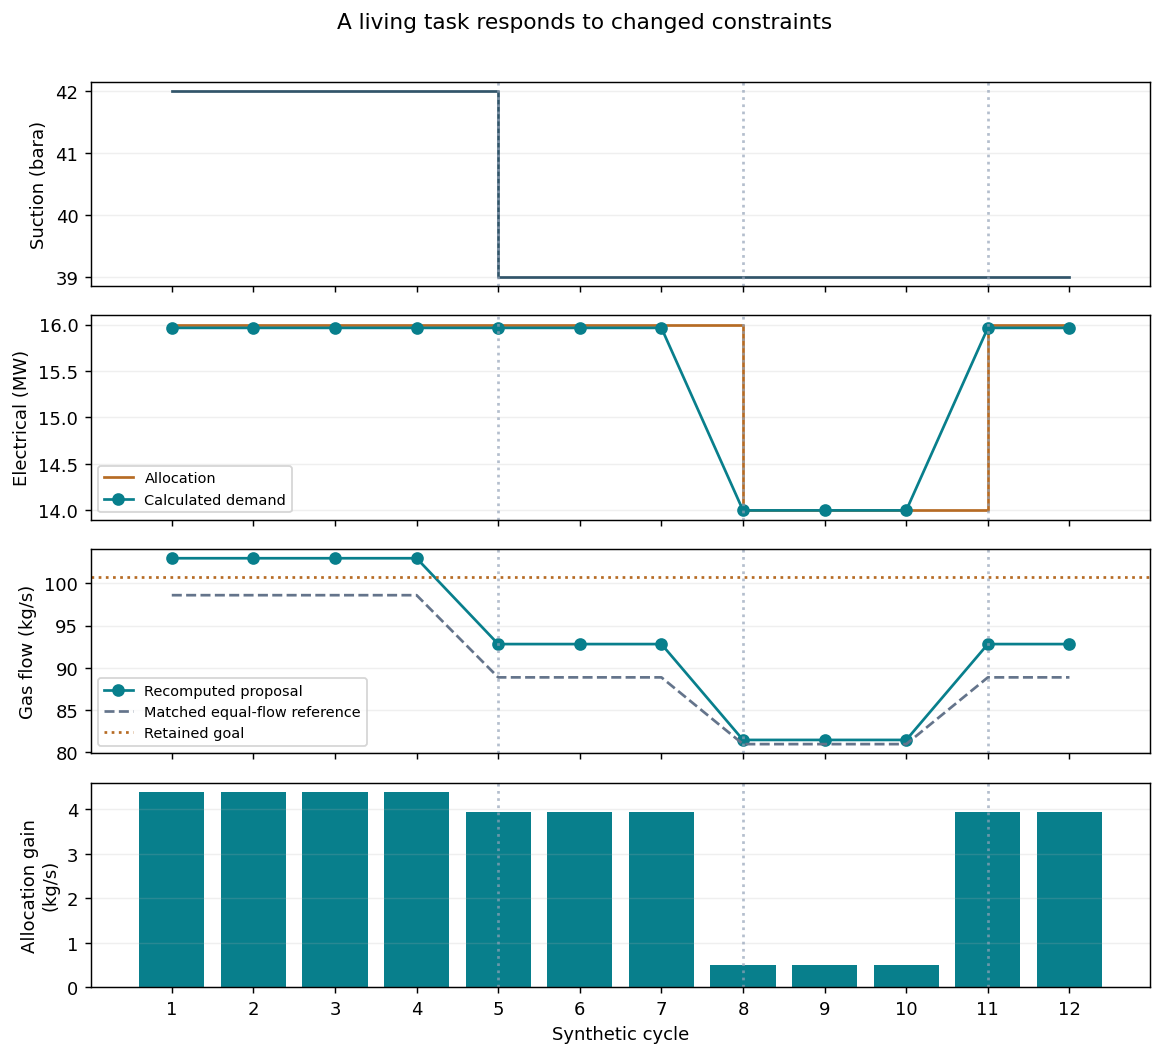

Cycle 5 invalidates: ['power_limits', 'electric_limit']
Cycle 8 invalidates: ['electric_limit']
Cycle 11 restores external power; this is not an agent-created gain.


In [9]:
fig, axes = plt.subplots(4, 1, figsize=(9, 8), sharex=True)
x = live_table["Cycle"]
axes[0].step(x, live_table["Suction bara"], where="post", color="#31556a")
axes[0].set_ylabel("Suction (bara)")
axes[1].step(x, live_table["Budget MW"], where="post", label="Allocation", color="#b66b24")
axes[1].plot(x, [row["selected"]["total_electric_power_mw"] for row in cycles],
             "o-", label="Calculated demand", color="#087f8c")
axes[1].set_ylabel("Electrical (MW)")
axes[1].legend(loc="lower left", fontsize=8)
axes[2].plot(x, live_table["Flow kg/s"], "o-", color="#087f8c", label="Recomputed proposal")
axes[2].plot(x, [row["reference"]["total_flow_kg_s"] for row in cycles],
             "--", color="#64748b", label="Matched equal-flow reference")
axes[2].axhline(GOAL_KG_S, color="#b66b24", linestyle=":", label="Retained goal")
axes[2].set_ylabel("Gas flow (kg/s)")
axes[2].legend(loc="lower left", fontsize=8)
axes[3].bar(x, live_table["Matched gain kg/s"], color="#087f8c")
axes[3].set(xlabel="Synthetic cycle", ylabel="Allocation gain\n(kg/s)", xticks=range(1, 13))
for axis in axes:
    for event in [5, 8, 11]:
        axis.axvline(event, color="#94a3b8", linestyle=":", alpha=0.7)
    axis.grid(axis="y", alpha=0.2)
fig.suptitle("A living task responds to changed constraints", y=1.01)
plt.tight_layout()
plt.show()
print("Cycle 5 invalidates:", cycles[4]["old_violations"])
print("Cycle 8 invalidates:", cycles[7]["old_violations"])
print("Cycle 11 restores external power; this is not an agent-created gain.")

## 5. Check the physics and numerical evidence
Mass and energy closure verify the calculation bookkeeping, not the validity of
the EOS or fixed-efficiency assumption. Repeatability and directional sensitivity
are useful checks; vendor maps and independent measured data remain necessary
before operational recommendations. The book's released-JAR results and this
source-build calculation have separate provenance.

In [10]:
repeat = evaluate(best["flows_kg_s"], best["inlet_c"])
degraded = capacity(best["inlet_c"], efficiencies=[0.79, 0.71, 0.81])
eta_low = capacity(best["inlet_c"], efficiencies=[value - 0.01 for value in EFFICIENCIES])
eta_high = capacity(best["inlet_c"], efficiencies=[value + 0.01 for value in EFFICIENCIES])
checks = {
    "all_initial_trials_feasible": all(row["feasible"] for row in trials),
    "mass_balance": max(row["mass_error_kg_s"] for row in trials) < 1e-6,
    "energy_balance": max(row["energy_error_w"] for row in trials) < 10.0,
    "repeatable_power": abs(repeat["total_shaft_power_mw"] - best["total_shaft_power_mw"]) < 1e-7,
    "efficiency_loss_reduces_capacity": degraded["total_flow_kg_s"] < best["total_flow_kg_s"],
    "efficiency_sensitivity_ordered": eta_low["total_flow_kg_s"] < best["total_flow_kg_s"]
        < eta_high["total_flow_kg_s"],
    "pressure_change_invalidates_old_plan": not cycles[4]["old_plan_feasible"],
    "curtailment_invalidates_old_plan": not cycles[7]["old_plan_feasible"],
    "all_replay_proposals_feasible": all(row["selected"]["feasible"] for row in cycles),
}
assert all(checks.values()), checks
display(pd.DataFrame(checks.items(), columns=["Check", "Passed"]))
print("Maximum mass residual (kg/s):", max(row["mass_error_kg_s"] for row in trials))
print("Maximum energy residual (W):", max(row["energy_error_w"] for row in trials))
print("Efficiency ±0.01 flow interval (kg/s):",
      round(eta_low["total_flow_kg_s"], 3), round(eta_high["total_flow_kg_s"], 3))

,Check,Passed
0,all_initial_trials_feasible,True
1,mass_balance,True
2,energy_balance,True
3,repeatable_power,True
4,efficiency_loss_reduces_capacity,True
5,efficiency_sensitivity_ordered,True
6,pressure_change_invalidates_old_plan,True
7,curtailment_invalidates_old_plan,True
8,all_replay_proposals_feasible,True


Maximum mass residual (kg/s): 2.842170943040401e-14
Maximum energy residual (W): 7.450580596923828e-09
Efficiency ±0.01 flow interval (kg/s): 101.67 104.299


## 6. Load the real public agent and skill instructions
The core agent, Community Agent and their required skills are versioned Markdown
instructions. They do not run by themselves. This adapter supplies a language
model, memory and the limited tools below. It does **not** silently execute shell
commands mentioned in the documents. Calibration and Bayesian search methods are
context for further investigations, not capabilities demonstrated by this notebook.

Every file is fetched from its pinned public commit and checked by SHA-256.
Local validation may use `NEQSIM_AGENT_DOCS_DIR`, a cache of those exact documents
retrieved through GitHub; the same hashes are mandatory. If a document changes or
cannot be fetched, stop rather than substituting another agent.

In [11]:
AGENT_DOCUMENTS = [
    {
        "name": "core_agent",
        "url": "https://raw.githubusercontent.com/equinor/neqsim/c53327e166448312291b4023c24b58f989c05a33/.github/agents/continuous-improvement.agent.md",
        "sha256": "3accb944283f013a32997b269402d14c5ea7765e53e697df819bc19808bc29a4"
    },
    {
        "name": "living_skill",
        "url": "https://raw.githubusercontent.com/equinor/neqsim/c53327e166448312291b4023c24b58f989c05a33/.github/skills/neqsim-continuous-task-improvement/SKILL.md",
        "sha256": "4e75549c194ff5ab9adbc1a7faca2c5b34ac703571a06e7d283eb32dec25b4fa"
    },
    {
        "name": "calibration_skill",
        "url": "https://raw.githubusercontent.com/equinor/neqsim/c53327e166448312291b4023c24b58f989c05a33/.github/skills/neqsim-model-calibration-and-data-reconciliation/SKILL.md",
        "sha256": "53ddff3eaaca0f31555cf99fbe3faaf398b83b4a06749f4cd1b4c1ef283f15b3"
    },
    {
        "name": "community_agent",
        "url": "https://raw.githubusercontent.com/equinor/neqsim-community-agents/6e72612fa947fd618db804d66e40fc7c47b15155/agents/continuous-task-improvement-agent/AGENT.md",
        "sha256": "466a5b9bf53bee2a510af8d1453c831c08a6babae3bf25857c95985a9409e5df"
    },
    {
        "name": "toolkit_skill",
        "url": "https://raw.githubusercontent.com/equinor/neqsim-community-skills/e2ac3307092ee375029c9551dd332ebd6ef78d56/skills/process/neqsim-continuous-improvement-toolkit/SKILL.md",
        "sha256": "7464e0fd4d6e712f25cfb379de544ee5485541f8cd5f08b056b9b4356787a162"
    }
]

In [12]:
import urllib.request

agent_documents = {}
document_evidence = []
cache_dir = os.environ.get("NEQSIM_AGENT_DOCS_DIR")
for document in AGENT_DOCUMENTS:
    if cache_dir:
        raw = (Path(cache_dir) / (document["name"] + ".md")).read_bytes()
        route = "verified local GitHub-document cache"
    else:
        with urllib.request.urlopen(document["url"], timeout=30) as response:
            raw = response.read()
        route = "pinned public URL"
    digest = hashlib.sha256(raw).hexdigest()
    assert digest == document["sha256"], "Instruction hash mismatch: " + document["name"]
    agent_documents[document["name"]] = raw.decode("utf-8")
    document_evidence.append({"Document": document["name"], "Route": route, "SHA-256": digest})
display(pd.DataFrame(document_evidence))
display(Markdown("### Loaded Community Agent (excerpt)\n" +
                 agent_documents["community_agent"].split("# Purpose", 1)[1].split("# When", 1)[0]))

,Document,Route,SHA-256
0,core_agent,pinned public URL,3accb944283f013a32997b269402d14c5ea7765e53e697...
1,living_skill,pinned public URL,4e75549c194ff5ab9adbc1a7faca2c5b34ac703571a06e...
2,calibration_skill,pinned public URL,53ddff3eaaca0f31555cf99fbe3faaf398b83b4a06749f...
3,community_agent,pinned public URL,466a5b9bf53bee2a510af8d1453c831c08a6babae3bf25...
4,toolkit_skill,pinned public URL,7464e0fd4d6e712f25cfb379de544ee5485541f8cd5f08...


### Loaded Community Agent (excerpt)


A solved engineering task is usually a snapshot: the report is right on the day it
is written and quietly goes stale as the plant, the data and the model move on.
This agent keeps the task alive. The NeqSim living-task runner does the routine
work deterministically — pull new evidence, recompute KPIs, detect drift, compare
with the promoted baseline, update an improvement ledger — and the agent is used
only for the exceptions: compiling a brief into a goal, tuning the monitoring by
backtest, triaging a triggered cycle, and preparing the decisions a reviewer
must take.



## 7. Give the agent bounded tools and retain its evidence
The agent may read the current snapshot, evaluate a cooling temperature with
power-limited allocation, and submit one of the candidates it has actually
calculated. It cannot alter the snapshot, relax constraints, invent a candidate
ID, execute arbitrary code or promote a baseline. The deterministic exhaustive
reference remains separate from what the agent has investigated.

The driver logs each tool call and result. The final recommendation is a validated
candidate reference plus the model's short rationale, not an unverified number
parsed from free text. The runtime limits rounds and calls and stops on invalid
arguments. A missing feasible proposal stays unresolved.

In [23]:
TOOLS = [
    {
        "type": "function", "name": "read_cycle", "description": "Read current qualified snapshot.",
        "strict": True,
        "parameters": {"type": "object", "properties": {}, "required": [],
                       "additionalProperties": False},
    },
    {
        "type": "function", "name": "evaluate_candidate",
        "description": "Run NeqSim at the chosen inlet temperature with bounded flow allocation.",
        "strict": True,
        "parameters": {
            "type": "object",
            "properties": {"inlet_c": {"type": "integer", "enum": list(range(29, 38))}},
            "required": ["inlet_c"], "additionalProperties": False,
        },
    },
    {
        "type": "function", "name": "submit_proposal",
        "description": "Submit a previously evaluated feasible candidate for human review.",
        "strict": True,
        "parameters": {
            "type": "object",
            "properties": {"candidate_id": {"type": "string"}, "rationale": {"type": "string"}},
            "required": ["candidate_id", "rationale"], "additionalProperties": False,
        },
    },
]

class EngineeringTools:
    def __init__(self, snapshot, previous_proposal):
        self.snapshot = dict(snapshot)
        self.previous = previous_proposal
        self.candidates = {}
        self.log = []
        self.proposal = None

    def call(self, name, arguments):
        if len(self.log) >= 12:
            raise RuntimeError("Tool-call budget exhausted")
        if name == "read_cycle" and arguments == {}:
            previous_check = evaluate(
                self.previous["flows_kg_s"], self.previous["inlet_c"],
                suction_bara=self.snapshot["suction_bara"],
                available_electric_mw=self.snapshot["available_electric_mw"],
            )
            result = {
                **self.snapshot, "goal_kg_s": GOAL_KG_S,
                "previous_plan_feasible": previous_check["feasible"],
                "previous_plan_violations": [
                    key for key, passed in previous_check["checks"].items() if not passed
                ],
                "previous_proposal": self.previous,
            }
        elif name == "evaluate_candidate" and set(arguments) == {"inlet_c"}:
            temperature = arguments["inlet_c"]
            if type(temperature) is not int or temperature not in range(29, 38):
                raise ValueError("Temperature must be an integer from 29 to 37 °C")
            candidate = capacity(
                temperature, suction_bara=self.snapshot["suction_bara"],
                available_electric_mw=self.snapshot["available_electric_mw"],
            )
            candidate_id = "candidate-" + str(len(self.candidates) + 1)
            self.candidates[candidate_id] = candidate
            result = {"candidate_id": candidate_id, **candidate}
        elif name == "submit_proposal" and set(arguments) == {"candidate_id", "rationale"}:
            candidate_id = arguments["candidate_id"]
            rationale = arguments["rationale"]
            if candidate_id not in self.candidates:
                raise ValueError("Proposal must reference an evaluated candidate")
            candidate = self.candidates[candidate_id]
            if not candidate["feasible"]:
                raise ValueError("Cannot submit an infeasible candidate")
            if not isinstance(rationale, str) or not 1 <= len(rationale) <= 3000:
                raise ValueError("Provide a brief rationale")
            self.proposal = {
                "candidate_id": candidate_id, "candidate": candidate,
                "model_rationale_unverified": rationale,
                "goal_met": candidate["total_flow_kg_s"] >= GOAL_KG_S,
                "decision_status": "proposal_only", "implemented": False,
            }
            result = self.proposal
        else:
            raise ValueError("Unknown tool or invalid argument keys")
        self.log.append({"tool": name, "arguments": arguments, "result": result})
        return result

ADAPTER_RULES = """
You are the engineering investigation agent for a SYNTHETIC compressor study.
Follow the public instructions as applicable, within the tools exposed here.
Do not execute commands mentioned in documents. No shell or plant-control tool exists.
Read the cycle, evaluate useful candidates, then submit a checked candidate ID.
You may use at most 12 response rounds and 12 tool calls. Candidate temperatures are 29–37 C.
Keep the throughput goal 100.8 kg/s. Explain any shortfall. Never relax limits.
A restored external power budget is not an agent-created gain.
Do not call a screening result a vendor-qualified or implemented operating change.
Distinguish your choice of investigation from deterministic allocation inside each tool.
Submit for human review; never claim acceptance, implementation or verified operating gain.
"""
INSTRUCTIONS = ADAPTER_RULES + "\n\n" + "\n\n".join(agent_documents.values())

def run_agent(responder, snapshot, previous_proposal, mode):
    runtime = EngineeringTools(snapshot, previous_proposal)
    messages = [{"role": "user", "content": (
        "Investigate this cycle. Check the old plan, compare cooling alternatives, "
        "and submit a feasible proposal with its limitations."
    )}]
    for round_number in range(12):
        items = responder(messages, TOOLS, INSTRUCTIONS)
        messages.extend(items)
        calls = [item for item in items if item.get("type") == "function_call"]
        if not calls:
            break
        for call in calls:
            result = runtime.call(call["name"], json.loads(call["arguments"]))
            messages.append({
                "type": "function_call_output", "call_id": call["call_id"],
                "output": json.dumps(result, allow_nan=False),
            })
            if runtime.proposal is not None:
                return {"mode": mode, "status": "proposal_for_review",
                        "proposal": runtime.proposal, "tool_log": runtime.log}
    return {"mode": mode, "status": "no_proposal_within_budget",
            "proposal": None, "tool_log": runtime.log}

### Exercise the complete tool loop without pretending it is an LLM
The following **scripted teaching replay** is a test driver with predetermined
calls. It verifies the same dispatcher and state transitions used by the optional
API mode. It is not evidence that a language model found the solution.
Read the resulting table: each row is a real NeqSim calculation or a checked
proposal transition.

In [24]:
class ScriptedTeachingResponder:
    def __init__(self):
        self.step = 0

    def __call__(self, messages, tools, instructions):
        sequence = [
            ("read_cycle", {}),
            ("evaluate_candidate", {"inlet_c": 37}),
            ("evaluate_candidate", {"inlet_c": 29}),
            ("submit_proposal", {
                "candidate_id": "candidate-2",
                "rationale": "Scripted teaching choice: compare 37 and 29 °C; retain the feasible "
                             "higher-flow trial for review, with fixed-efficiency limitations.",
            }),
        ]
        name, arguments = sequence[self.step]
        self.step += 1
        return [{"type": "function_call", "name": name,
                 "call_id": f"teaching-{self.step}", "arguments": json.dumps(arguments)}]

demo_run = run_agent(ScriptedTeachingResponder(), snapshots[4], best, "scripted_teaching_replay")
assert demo_run["status"] == "proposal_for_review"
assert demo_run["proposal"]["candidate"]["feasible"]
display(pd.DataFrame([{
    "Step": number, "Tool": item["tool"], "Arguments": json.dumps(item["arguments"]),
    "Flow kg/s": item["result"].get("total_flow_kg_s"),
    "Feasible": item["result"].get("feasible"),
} for number, item in enumerate(demo_run["tool_log"], 1)]))
print("Status:", demo_run["status"])
print("Goal met:", demo_run["proposal"]["goal_met"])
print("Decision:", demo_run["proposal"]["decision_status"])

# Meaningful boundaries: outside-range trials and fabricated candidate IDs fail.
for tool_name, arguments in [
    ("evaluate_candidate", {"inlet_c": 10}),
    ("submit_proposal", {"candidate_id": "invented", "rationale": "unsupported"}),
    ("run_shell", {"command": "echo forbidden"}),
]:
    test_runtime = EngineeringTools(snapshots[4], best)
    try:
        test_runtime.call(tool_name, arguments)
    except ValueError:
        print("Rejected as required:", tool_name, arguments)
    else:
        raise AssertionError("An invalid tool request was accepted")

,Step,Tool,Arguments,Flow kg/s,Feasible
0,1,read_cycle,{},NaN,None
1,2,evaluate_candidate,"{""inlet_c"": 37}",89.807782,True
2,3,evaluate_candidate,"{""inlet_c"": 29}",92.799679,True
3,4,submit_proposal,"{""candidate_id"": ""candidate-2"", ""rationale"": ""...",NaN,None


Status: proposal_for_review
Goal met: False
Decision: proposal_only
Rejected as required: evaluate_candidate {'inlet_c': 10}
Rejected as required: submit_proposal {'candidate_id': 'invented', 'rationale': 'unsupported'}
Rejected as required: run_shell {'command': 'echo forbidden'}


### Example report format with actual computed evidence
This report is a transparent Python template based on the scripted teaching
run, **not** text generated by a language model and **not** a prediction of what
any model will choose. It shows the kind of evidence a useful agent report should
contain. In live mode, the model's own rationale and actual tool log are displayed
separately and must be assessed against the numerical evidence.

In [25]:
proposal = demo_run["proposal"]["candidate"]
shortfall = max(0.0, GOAL_KG_S - proposal["total_flow_kg_s"])
example_report = (
    "**Illustrative report — computed results, templated wording**\n\n"
    "Suction pressure fell from 42 to 39 bara. The previous proposal now exceeds "
    "train shaft-power limits and must not be reused as feasible.\n\n"
    f"The checked {proposal['inlet_c']:.0f} °C candidate processes "
    f"**{proposal['total_flow_kg_s']:.2f} kg/s**, consuming "
    f"{proposal['total_electric_power_mw']:.2f} MW within the 16 MW allocation. "
    f"All modeled feasibility checks pass. The retained 100.8 kg/s goal has a "
    f"**{shortfall:.2f} kg/s shortfall**.\n\n"
    "This is a screening proposal for engineer review. Check compressor maps, "
    "cooling availability and data quality before acceptance. No operating "
    "change has been implemented or independently verified."
)
display(Markdown(example_report))

**Illustrative report — computed results, templated wording**

Suction pressure fell from 42 to 39 bara. The previous proposal now exceeds train shaft-power limits and must not be reused as feasible.

The checked 29 °C candidate processes **92.80 kg/s**, consuming 15.96 MW within the 16 MW allocation. All modeled feasibility checks pass. The retained 100.8 kg/s goal has a **8.00 kg/s shortfall**.

This is a screening proposal for engineer review. Check compressor maps, cooling availability and data quality before acceptance. No operating change has been implemented or independently verified.

### Check the API adapter without spending a key
A local HTTP mock exercises the actual installed OpenAI SDK and the complete
tool loop. It checks serialized requests and returned function-call objects.
This tests integration mechanics only; it does not establish model behavior or
account/model availability.

In [26]:
from openai import OpenAI
import httpx2 as httpx


def make_openai_responder(client, model):
    def respond(messages, tools, instructions):
        response = client.responses.create(
            model=model, instructions=instructions, input=messages,
            tools=tools, parallel_tool_calls=False, max_output_tokens=2500, store=False,
        )
        return [item.model_dump(exclude_none=True) for item in response.output]
    return respond


# Test the real SDK request/response adapter with a local mock transport.
# This performs NO external API call and is NOT a language-model evaluation.
scripted_transport = ScriptedTeachingResponder()
requests_checked = []

def mock_api(request):
    payload = json.loads(request.content)
    assert payload["store"] is False
    assert payload["parallel_tool_calls"] is False
    assert len(payload["tools"]) == 3
    requests_checked.append(payload["model"])
    output = scripted_transport(payload["input"], payload["tools"], payload["instructions"])
    for item in output:
        item["id"] = "fc_" + item["call_id"]
        item["status"] = "completed"
    return httpx.Response(200, json={
        "id": "resp_transport_test", "object": "response", "created_at": 0,
        "status": "completed", "model": "mock-only", "output": output,
    })

with OpenAI(
    api_key="mock-transport-placeholder",
    http_client=httpx.Client(transport=httpx.MockTransport(mock_api)),
    max_retries=0,
) as mock_client:
    sdk_test = run_agent(
        make_openai_responder(mock_client, "mock-only"), snapshots[4], best,
        "mock_sdk_transport_test",
    )
assert len(requests_checked) == 4
assert sdk_test["proposal"]["candidate"]["feasible"]
print("SDK adapter test passed: four local mocked Responses exchanges.")
print("External API requests: zero. Language-model quality: not evaluated.")

SDK adapter test passed: four local mocked Responses exchanges.
External API requests: zero. Language-model quality: not evaluated.


## 8. Connect your own language model and run a real investigation
**Exactly where to enter the settings in Google Colab:**
1. Run Sections 1–7 first, or use Runtime → Run all with `RUN_LLM = False`.
2. Open the key icon in the left sidebar (Secrets). Add a secret named
   `OPENAI_API_KEY`, paste your API key as its value and enable notebook access.
3. In the next code cell's `LLM_MODEL` field, enter an exact API model ID that your
   account can use and that supports Responses API function calling.
4. Set `RUN_LLM` to `True`, then run that code cell. Its output shows each
   event, actual tool calls, checked results and the model's rationale.
5. Rerun Section 9 to save the handoff including the live run. Review saved
   outputs before sharing; never paste the key into code, Markdown or a prompt.

This runnable adapter uses the OpenAI Responses API function-calling interface.
Set `RUN_LLM = True` and enter a model ID available to your API account. Store
`OPENAI_API_KEY` in Colab Secrets (the key icon), or an environment variable.
The key is read without printing it; do not paste it into a saved code cell.
Only the synthetic case, selected public instructions and tool results are sent.
Requests may incur API charges. Calls are bounded; no background service is started.

The API mode is **off by default**. Saved publication outputs honestly report
whether a real provider run occurred. The tested scripted loop does not replace a
live-provider evaluation. Gemini or another provider can be added by writing a
`responder(messages, tools, instructions)` adapter with the same contract; no
Gemini adapter is claimed here.

The optional loop reacts to cycles 1, 5, 8 and 11. It carries the last hypothetical
proposal forward and retains each model-selected calculation, so the reader can
compare actual agent choices with the exhaustive deterministic reference.

In [27]:
RUN_LLM = False  # @param {type:"boolean"}
LLM_MODEL = "gpt-5.4"  # @param {type:"string"}

from openai import OpenAI

llm_runs = []
if RUN_LLM:
    if not LLM_MODEL.strip():
        raise ValueError("Enter an API model ID supported by your account in LLM_MODEL.")
    api_key = os.environ.get("OPENAI_API_KEY")
    if not api_key and "google.colab" in sys.modules:
        from google.colab import userdata
        api_key = userdata.get("OPENAI_API_KEY")
    if not api_key:
        raise ValueError("Add OPENAI_API_KEY to Colab Secrets or the environment.")
    client = OpenAI(api_key=api_key, timeout=90, max_retries=0)

    openai_responder = make_openai_responder(client, LLM_MODEL.strip())

    previous_proposal = best
    for index in [0, 4, 7, 10]:
        outcome = run_agent(
            openai_responder, snapshots[index], previous_proposal, "live_openai_api",
        )
        outcome["cycle"] = snapshots[index]["cycle"]
        outcome["model"] = LLM_MODEL.strip()
        llm_runs.append(outcome)
        print("Cycle", outcome["cycle"], outcome["status"])
        display(pd.DataFrame([{
            "Tool": item["tool"], "Arguments": json.dumps(item["arguments"]),
            "Flow kg/s": item["result"].get("total_flow_kg_s"),
        } for item in outcome["tool_log"]]))
        if outcome["proposal"] is None:
            print("No checked proposal: retain the unresolved state for engineer review.")
            break
        previous_proposal = outcome["proposal"]["candidate"]
        display(Markdown(outcome["proposal"]["model_rationale_unverified"]))
        print("Goal met:", outcome["proposal"]["goal_met"], "; proposal only, not implemented.")
else:
    print("LIVE LANGUAGE-MODEL MODE NOT RUN: no API request was made.")
    print("Set RUN_LLM=True, configure LLM_MODEL and supply your own API key to run it.")

Cycle 1 proposal_for_review


,Tool,Arguments,Flow kg/s
0,read_cycle,{},NaN
1,evaluate_candidate,"{""inlet_c"": 29}",102.984773
2,evaluate_candidate,"{""inlet_c"": 30}",102.544641
3,evaluate_candidate,"{""inlet_c"": 31}",102.109224
4,evaluate_candidate,"{""inlet_c"": 32}",101.678436
5,evaluate_candidate,"{""inlet_c"": 33}",101.252192
6,submit_proposal,"{""candidate_id"": ""candidate-1"", ""rationale"": ""...",NaN


Reviewed the old plan against bounded cooling alternatives at 42.0 bara suction and unchanged limits. Previous plan was feasible with no violations. I re-evaluated 29–33 C inlet cases. All checked cases remained feasible, but throughput decreased monotonically as inlet temperature increased: 29 C = 102.985 kg/s, 30 C = 102.545 kg/s, 31 C = 102.109 kg/s, 32 C = 101.678 kg/s, 33 C = 101.252 kg/s. Therefore the coldest tested case, 29 C, is the best feasible alternative among those reviewed and preserves the largest margin above the 100.8 kg/s goal. Selected candidate-1 for human review. Limitations: this is an investigation result for the tested inlet-temperature alternatives only; deterministic flow allocation was done inside the evaluation tool, not chosen manually here. The apparent margin comes from the restored 16.0 MW external electric availability already present in the cycle snapshot, not from an agent-created gain. This submission is not a vendor-qualified or implemented operating change, only a feasible proposal for review.

Goal met: True ; proposal only, not implemented.
Cycle 5 proposal_for_review


,Tool,Arguments,Flow kg/s
0,read_cycle,{},NaN
1,evaluate_candidate,"{""inlet_c"": 29}",92.799679
2,evaluate_candidate,"{""inlet_c"": 30}",92.412058
3,evaluate_candidate,"{""inlet_c"": 31}",92.028471
4,evaluate_candidate,"{""inlet_c"": 32}",91.648847
5,evaluate_candidate,"{""inlet_c"": 33}",91.273116
6,evaluate_candidate,"{""inlet_c"": 34}",90.901209
7,evaluate_candidate,"{""inlet_c"": 35}",90.533061
8,evaluate_candidate,"{""inlet_c"": 36}",90.168606
9,evaluate_candidate,"{""inlet_c"": 37}",89.807782


...

Cycle 8 investigation reviewed the old plan and compared all allowed inlet cooling alternatives from 29 to 37 C at suction 39.0 bara with the restored available electric power limited to 14.0 MW. The old plan is no longer feasible because it required 15.964 MW electric, violating the electric limit, even though it had previously been feasible at 16.0 MW and 92.80 kg/s. All newly evaluated alternatives were constraint-feasible, but none could achieve the 100.8 kg/s throughput goal without relaxing limits. The best feasible alternative among the checked inlet temperatures is 29 C (candidate-1), which maximizes total flow at 81.43 kg/s while satisfying electric, cooling, temperature, pressure, mass balance, energy balance, and flow checks. This remains 19.37 kg/s below the 100.8 kg/s goal because the active hard constraint is the reduced 14.0 MW electric power budget; colder inlet cooling helps relative to warmer cases, but not enough to recover target throughput within limits. Limitations: this is an investigation result for human review only, based on deterministic allocation inside the evaluation tool for each tested inlet temperature; it is not a vendor-qualified or implemented operating change, and no verified operating gain is claimed. The apparent loss versus the old plan comes from the lower available electric budget, not from any agent-created gain or change.

Goal met: False ; proposal only, not implemented.
Cycle 11 proposal_for_review


,Tool,Arguments,Flow kg/s
0,read_cycle,{},NaN
1,evaluate_candidate,"{""inlet_c"": 29}",92.799679
2,evaluate_candidate,"{""inlet_c"": 30}",92.412058
3,evaluate_candidate,"{""inlet_c"": 31}",92.028471
4,evaluate_candidate,"{""inlet_c"": 32}",91.648847
5,evaluate_candidate,"{""inlet_c"": 33}",91.273116
6,evaluate_candidate,"{""inlet_c"": 34}",90.901209
7,evaluate_candidate,"{""inlet_c"": 35}",90.533061
8,evaluate_candidate,"{""inlet_c"": 36}",90.168606
9,evaluate_candidate,"{""inlet_c"": 37}",89.807782


Investigated the old feasible plan and compared inlet-cooling alternatives from 29 to 37 C under unchanged hard limits and a 100.8 kg/s target. The prior plan at 29 C was feasible at 14.0 MW electric but achieved only 81.43 kg/s. Re-evaluation with the current restored 16.0 MW electric budget shows all alternatives remain feasible, and 29 C is the best of the screened options. Candidate-1 delivers 92.80 kg/s total with flows [31.20, 29.62, 31.99] kg/s, total electric power 15.964 MW, inlet cooling 1.789 MW, and all checks passing. Throughput decreases monotonically as inlet temperature increases to 37 C, so no warmer cooling alternative is better. Limitation: this best feasible case is still 8.00 kg/s below the 100.8 kg/s goal. The shortfall is explained by all three trains being driven to about 5 MW shaft each under bounded allocation, so current compressor/power capacity remains limiting at these suction and inlet conditions. Submitted for human review only; not an implemented or vendor-qualified operating change, and no verified gain is claimed.

Goal met: False ; proposal only, not implemented.


### Recorded API investigation (27 September 2026)
The saved output immediately above was supplied by Even Solbraa from an opt-in Colab run with `RUN_LLM = True` and `gpt-5.4`. All four cycles (1, 5, 8, 11) returned a checked feasible candidate for **human review**, with screened flows 102.985, 92.800, 81.427 and 92.800 kg/s respectively. Only cycle 1 meets the 100.8 kg/s goal; a shortfall in the other cycles does not mean the proposals failed validation. The candidate feasibility and flow values come from the NeqSim-backed tools; the model-written explanations displayed above are **unverified text**.

**Corrections to the model explanations:** In cycle 8, throughput rises from 79.088 kg/s at 36 °C to 79.353 kg/s at 37 °C. The statement that it decreases monotonically over 29–37 °C is false. The example removes 0.10 MW of cooling auxiliary load at 37 °C, which explains this step in the model. The best of the tested temperatures remains 29 °C. The 14.0 MW budget in cycle 8 is a **reduction**, and 16.0 MW in cycle 1 is the initial budget, not a restoration. External power is restored in cycle 11. These corrections leave the checked candidate values intact.

For the recorded run, the controller permitted 12 response rounds while the prompt said six; the prompt has been aligned with the controller for future executions. These saved outputs reflect the original prompt. The scripted reference and physics checks remain separate. The toggle in the cell above is restored to `False` for a safe future **Run all**; switch it to `True` deliberately to make new paid API calls. The saved output reflects the previous opt-in execution, and rerunning with the toggle off will replace that output. No API credential is stored here.


## 9. Preserve the living task and compare improvements honestly
The handoff below contains the model basis, source provenance, cycle history,
instruction hashes and tool logs. A real deployment would replace synthetic
snapshots with a qualified read-only data adapter, persist state outside Colab,
schedule the deterministic monitor and invoke the agent only on relevant changes.
Colab runtime lifetime is not a production scheduler.

An engineer must separately review constraints, uncertainty, equipment maps and
measurement quality before accepting a proposal. The book's native
`task-living`, `task-cycle`, ledger and promotion workflow provides the deployment
pattern; this notebook does not claim to execute that complete CLI workflow.
Do not reuse stale power allocations. Missing or unqualified inputs should block
new operating proposals, with the data problem retained in the task history.

In [28]:
handoff = {
    "schema_version": "1.0.0",
    "case": "synthetic_three_train_compressor",
    "goal_kg_s": GOAL_KG_S,
    "provenance": PROVENANCE,
    "composition": COMPOSITION,
    "instruction_documents": AGENT_DOCUMENTS,
    "checks": checks,
    "initial_best": best,
    "cycles": cycles,
    "scripted_teaching_run": demo_run,
    "live_language_model_runs": llm_runs,
    "live_language_model_executed": bool(llm_runs),
    "plant_connected": False,
    "operating_change_implemented": False,
}
output_path = Path("continuous_compressor_handoff.json")
output_path.write_text(json.dumps(handoff, indent=2, allow_nan=False), encoding="utf-8")
print("Saved:", output_path.resolve())
print("SHA-256:", hashlib.sha256(output_path.read_bytes()).hexdigest())
print("Initial flow:", round(best["total_flow_kg_s"], 3), "kg/s")
print("Low-pressure capacity:", round(cycles[4]["selected"]["total_flow_kg_s"], 3), "kg/s")
print("Curtailed-power capacity:", round(cycles[7]["selected"]["total_flow_kg_s"], 3), "kg/s")
print("Live language model executed:", bool(llm_runs))
print("All engineering checks:", all(checks.values()))

Saved: /content/continuous_compressor_handoff.json
SHA-256: bdfe55a405cf7ca7bb266c3025ed85c89c78618fcf152d65d255cd5c5036978a
Initial flow: 102.985 kg/s
Low-pressure capacity: 92.8 kg/s
Curtailed-power capacity: 81.427 kg/s
Live language model executed: True
All engineering checks: True


## Interpretation, exercises and limits
- Falling suction pressure invalidates the old power-limited proposal even if the
  nominal flow target is unchanged. The new achievable flow can be lower despite
  a successful optimization.
- Extra external power and agent-selected allocation are different causes. Report
  allocation gain against the matched reference, and never attribute the whole
  throughput recovery to the agent.
- The scripted demonstration proves tool plumbing and physics execution. The real
  model mode supports an experiment: compare tool calls, constraint violations,
  checked throughput, shortfall explanations and engineer review time against the
  deterministic reference under the same information budget.
- Add vendor maps, pressure losses or uncertain measurements one at a time. Then
  revisit the allocator and validity of every conclusion. Do not calibrate and
  validate against the same observations.
- No real event dataset, independent compressor benchmark, automatic setpoint
  control, representative provider evaluation or native scheduler integration is
  claimed. The four recorded provider proposals are screening results for
  engineer review, with model rationale corrected above where inconsistent
  with the numeric evidence. No NeqSim defect is established merely by
  these limitations.

### References and companion material
1. Even Solbraa (2026), *Continuous Agentic Engineering with NeqSim*, revised
   Chapter 9, “A complete teaching walkthrough”; Chapters 2, 5–7 and 11 supply
   the architecture, living-task workflow and comparison principles. The book
   revision is delivered separately as HTML/PDF; its bundled example used the
   released 3.20.0 JAR, while this notebook prints its source-master provenance.
2. [NeqSim continuous-task guide](https://github.com/equinor/neqsim/blob/master/docs/development/CONTINUOUS_TASK_SOLVING.md).
3. [Community Agents](https://github.com/equinor/neqsim-community-agents) and
   [Community Skills](https://github.com/equinor/neqsim-community-skills).
   Exact instruction files and hashes appear in Section 6.
4. [OpenAI function calling](https://developers.openai.com/api/docs/guides/function-calling).
5. Related broader workflow: [Agentic asset-team tieback and debottlenecking](agentic_asset_team_tieback_and_debottlenecking.ipynb).

**Documentation impact:** this example adds a reproducible companion to the book,
a bounded live-model adapter, retained teaching outputs and catalog/README entries.
It changes no NeqSim library API. Publication validation details are retained in
its maintenance-ledger shard.